# Feature analysis — executable template

**Copy this notebook to `notebooks/features/<feature>.ipynb` and swap your feature into
§2–§3.** It follows `notebooks/features/template.md` and reuses its harness: the merged
trade clock, a single shared vol yardstick `σ_ev`, an EMA feature builder + blind oracle,
and the regime-invariance gate machinery. The analysis is done when **§4 (oracle) and
§5 (hygiene gates)** both pass.

Worked example: `price_dislocation` — a cross-venue **log-price spread** run through a
**two-EMA oscillator** `(EMA_fast − EMA_slow)`, normalised by the shared `σ_ev`. A
directional feature for the price/direction head that *also* feeds the rate head; it
exercises the level-flavour EMA, best-fresh price stream per listing, the
normalizer-stability gate, head routing, and a 2-parameter feature **family**.

## 0. Metadata · 1. Hypothesis

| | |
|---|---|
| **name** | `price_dislocation_{listing}(N_fast, N_slow)` — keyed by listing; a 2-EMA oscillator on the basis |
| **head** | **both** — direction (price head, *signed*) + intensity (rate head, *\|·\|*); see Head routing |
| **clock** | merged trade · **family** N_fast < N_slow · **kind** level (spread → level-flavour EMA) |
| **mids** | best-fresh per listing: `bin`→front_levels (sub-ms; merged blocked), `byb/okx`→merged_levels |
| **L / T** | `{bin,byb,okx}_eth_usdt_p` / `byb_eth_usdt_p` (byb is both spread reference *and* target) |

**Definition.** `sₗ = log(mid_ℓ) − log(mid_byb)` is the cross-venue log-spread (basis);
the feature is a difference of two EMAs of it, in shared σ-units:
`price_dislocation_ℓ(N_fast, N_slow) = (EMA_{N_fast}[sₗ] − EMA_{N_slow}[sₗ]) / σ_ev`.
`N_fast=1` (EMA = the latest value) is the single-EMA special case `sₗ − EMA_{N_slow}[sₗ]`.

**Hypothesis.** When a venue richens vs byb (the basis sits above its slow level) byb
**catches up**, since the leader (bin) leads (nb03 ≈75 ms). So the basis mean-reverts and
the dislocation predicts byb's forward return *positively*. The slow leg sets the
reference; a lightly-smoothed fast leg denoises the "recent basis" read.
**Falsifier:** ~0 IC with byb's forward (σ-normalised) return across the family, or
signal only via the regime level (a leak).

## 2. Definition — the 2-EMA family (causal, dimensionless)

Design choices, all deliberate:
- **Difference of two EMAs (oscillator).** `EMA_fast − EMA_slow` band-passes the basis:
  the slow leg is the reference level, the fast leg the recent estimate. `N_fast=1` is the
  *noisy high-frequency edge* (every single-tick jitter lands in it); `N_fast>1` denoises.
- **Log-difference, not subtraction/ratio.** Prices are geometric → the basis must be
  scale-invariant: `log(mid_ℓ) − log(mid_byb)`, EMAs in log-space.
- **One shared vol yardstick `σ_ev`.** The forward target is `R_byb / σ_ev`, so the
  feature divides by the **same** `σ_ev` (byb's per-merged-tick mid-vol over
  `VOL_LOOKBACK` events) — feature and target share σ-units. `σ_ev` is on **byb (the
  target)**, *not* the spread's own vol.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # spread reference AND prediction target
OTHERS      = ["bin", "okx"]                      # listings we measure a basis-vs-byb for
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}  # best-fresh per listing
FAST        = [1, 10, 50, 200]                   # N_fast grid (1 = the single-EMA special case)
SLOW        = [100, 500, 2000, 5000]             # N_slow grid (must exceed N_fast)
HORIZON_NS  = 100 * 1_000_000                    # forward-return horizon
VOL_LOOKBACK = 10000                             # σ_ev window (merged events) — SHARED by feature & target
block       = list_blocks(TARGET, "front_levels")[0]

# best-fresh mid per listing
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc")
          .drop_nulls())                          # blocks are stored rx_time-sorted (see io.load_block)
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in ("bin", "byb", "okx")}

# merged TRADE clock: union of all venues' trade times, rx-ordered (the event clock ticks on trades)
trade_ts = []
for ex in ("bin", "byb", "okx"):
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop zero-prints
    trade_ts.append(td["rx_time"].cast(pl.Int64).to_numpy())
merged_ts = np.sort(np.concatenate(trade_ts), kind="stable")
n_ticks = len(merged_ts)
print(f"merged clock: {n_ticks:,} trades")

def mid_on_clock(ex):                              # causal forward-fill of a listing's mid onto every merged tick
    rx, mid = mids[ex]
    return mid[np.clip(np.searchsorted(rx, merged_ts, "right") - 1, 0, len(mid) - 1)]
log_mid_byb = np.log(mid_on_clock("byb"))

# shared σ_ev: trailing RMS of byb's per-merged-tick mid-return over VOL_LOOKBACK events (causal, exclusive)
byb_tick_return = np.zeros(n_ticks); byb_tick_return[1:] = np.diff(log_mid_byb)
cumsum_sq_return = np.concatenate([[0.0], np.cumsum(byb_tick_return ** 2)])
def sigma_ev(window):
    s = np.full(n_ticks, np.nan)
    s[window:] = np.sqrt((cumsum_sq_return[window:n_ticks] - cumsum_sq_return[:n_ticks - window]) / window)
    return s
sigma = sigma_ev(VOL_LOOKBACK)
print(f"σ_ev (byb, {VOL_LOOKBACK} events): median {np.nanmedian(sigma):.2e}")

merged clock: 6,198,188 trades


σ_ev (byb, 10000 events): median 4.48e-06


## 3. Construction (vectorized for analysis; O(1) streaming in production)

The streaming feature is two level-flavour `ScalarEMA`s of `sₗ` (fast + slow) per
(listing, scale) plus the shared `σ_ev`; here the analysis form is two constant-α
`lfilter`s on the spread, differenced and read at the grid.

In [2]:
# evaluation grid (causal) + forward target in shared σ-units
anchor_ts      = np.arange(merged_ts[50000], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last merged tick <= anchor
sigma_at_anchor = sigma[tick_at_anchor]

byb_rx, byb_mid = mids["byb"]
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # R_byb / σ_ev  (== nb05's σ-units target)

spreads = {ex: np.log(mid_on_clock(ex)) - log_mid_byb for ex in OTHERS}   # cross-venue log-spread per listing
def ema(spread, N):
    if N == 1: return spread                                       # all weight on the latest tick
    a = 2.0 / (N + 1.0); return lfilter([a], [1.0, -(1.0 - a)], spread)
def price_dislocation(spread, n_fast, n_slow):     # (EMA_fast − EMA_slow) / σ_ev, read at the grid
    return ((ema(spread, n_fast) - ema(spread, n_slow))[tick_at_anchor]) / sigma_at_anchor
print(f"grid: {len(anchor_ts):,} anchors")

grid: 1,718,559 anchors


## 4. Oracle — HARD GATE (correctness)

`CLAUDE.md`: the vectorized feature must match a dead-simple, independent loop on a real
block. Stream every merged tick, keep both EMAs of the spread by hand, difference and
divide by `σ_ev` — must equal the `lfilter` version bit-for-bit.

In [3]:
def price_dislocation_oracle(spread, n_fast, n_slow):   # blind reference: explicit arrival-order loop, no lfilter
    af, as_ = 2.0 / (n_fast + 1.0), 2.0 / (n_slow + 1.0)
    ema_f = ema_s = 0.0; out = np.empty(n_ticks); s = spread.tolist()
    for tick in range(n_ticks):
        ema_f = (1.0 - af) * ema_f + af * s[tick]                  # fast level EMA (af=1 → ema_f = s)
        ema_s = (1.0 - as_) * ema_s + as_ * s[tick]                # slow level EMA
        out[tick] = ema_f - ema_s
    return out[tick_at_anchor] / sigma_at_anchor

assert np.allclose(price_dislocation_oracle(spreads["bin"], 10, 100),
                   price_dislocation(spreads["bin"], 10, 100), rtol=1e-9, atol=1e-12)
print(f"oracle: lfilter == arrival-order loop (bin, Nf=10, Ns=100), bit-equal on {n_ticks:,} ticks  OK")

oracle: lfilter == arrival-order loop (bin, Nf=10, Ns=100), bit-equal on 6,198,188 ticks  OK


## 5. Hygiene gates — HARD GATE (signal)

Regime base `[cr,cv]` (rate+vol momenta) and level controls `[lv,lr]` — vol terms reuse
the shared `σ_ev` — plus the OOS rank-IC harness, then the gates from `docs/feature_hygiene.md`.

In [4]:
# --- regime base (feature_hygiene.md shorthand in comments: cr,cv = momenta; lr,lv = levels) ---
def trailing_rate(window):                          # merged events/sec over the last `window` events
    j = np.clip(tick_at_anchor, window, None)
    return window / np.maximum((merged_ts[j] - merged_ts[j - window]) / 1e9, 1e-9)
rate_level    = np.log(trailing_rate(10000))                                      # lr
rate_momentum = np.log(trailing_rate(1000) / trailing_rate(10000))               # cr
vol_level     = np.log(sigma_at_anchor)                                           # lv  (the shared σ_ev)
vol_momentum  = np.log(sigma_ev(1000)[tick_at_anchor] / sigma_at_anchor)          # cv

def oos_rank_ic(features, y):                       # standardize on train(60%), fit, rank-IC on held-out test
    design = np.column_stack(features)
    valid  = np.isfinite(design).all(1) & np.isfinite(y)
    n = len(y); is_train = np.zeros(n, bool); is_train[:int(0.6 * n)] = True
    train, test = valid & is_train, valid & ~is_train
    mean, std = design[train].mean(0), design[train].std(0) + 1e-12
    model_in  = np.column_stack([(design - mean) / std, np.ones(n)])
    coef, *_  = np.linalg.lstsq(model_in[train], y[train], rcond=None)
    return float(spearmanr(model_in[test] @ coef, y[test]).statistic)

base, levels = [rate_momentum, vol_momentum], [rate_level, vol_level]
print("base IC -> byb fwd:  [cr,cv]", round(oos_rank_ic(base, target), 3),
      " [cr,cv,lv,lr]", round(oos_rank_ic(base + levels, target), 3))

/var/folders/m3/7cjs9hdj1qlgdfh3tq_9txmm0000gn/T/ipykernel_68529/2593355394.py:8: RuntimeWarning: divide by zero encountered in log
  vol_momentum  = np.log(sigma_ev(1000)[tick_at_anchor] / sigma_at_anchor)          # cv


base IC -> byb fwd:  [cr,cv] -0.003  [cr,cv,lv,lr] 0.004


## 5b. The family & head routing

Sweep the whole **(N_fast, N_slow) family** against *both* heads' targets — price head
wants *direction* (signed → σ-return), rate head wants *intensity* (`|·|` → forward
mid-move count). The two heads peak in **different corners**: smoothed-fast/slow for
direction, instantaneous-fast (`N_fast=1`)/fast-slow for intensity. The single-EMA
feature is just the top row (`N_fast=1`).

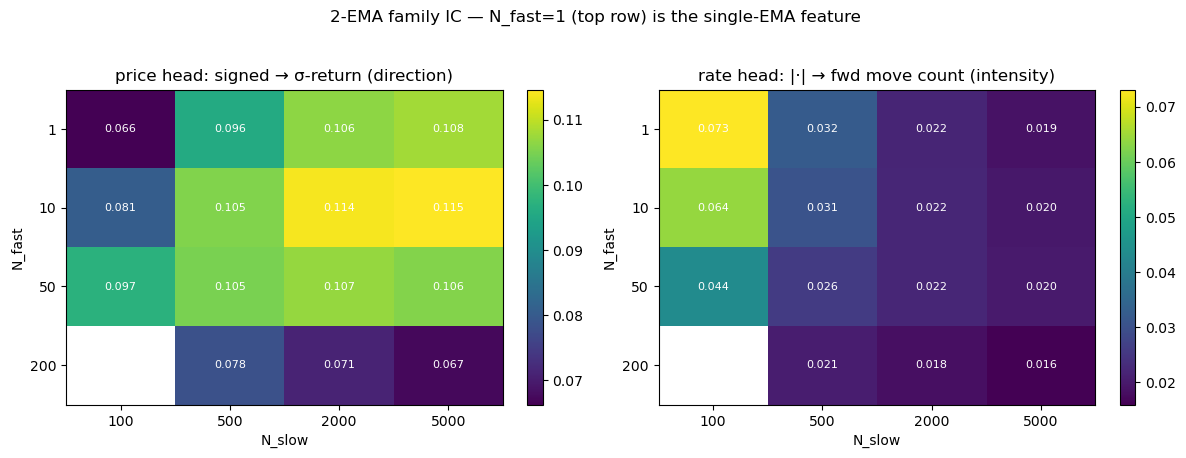

best PRICE-head member: (N_fast=10, N_slow=5000)  IC=0.115
best RATE-head  member: (N_fast=1, N_slow=100)  IC=0.073


In [5]:
# rate-head target: forward byb mid-move count
byb_move_ts = byb_rx[np.r_[False, np.diff(byb_mid) != 0]]
fwd_count = (np.searchsorted(byb_move_ts, anchor_ts + HORIZON_NS, "right")
             - np.searchsorted(byb_move_ts, anchor_ts, "right")).astype(float)

# IC of every family member (bin) for each head
price_grid = np.full((len(FAST), len(SLOW)), np.nan)   # signed → σ-return
rate_grid  = np.full((len(FAST), len(SLOW)), np.nan)   # |·|   → move count
for i, nf in enumerate(FAST):
    for j, ns in enumerate(SLOW):
        if nf >= ns: continue
        d = price_dislocation(spreads["bin"], nf, ns)
        price_grid[i, j] = spearmanr(d, target).statistic
        rate_grid[i, j]  = spearmanr(np.abs(d), fwd_count).statistic

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, grid, title in ((axes[0], price_grid, "price head: signed → σ-return (direction)"),
                        (axes[1], rate_grid, "rate head: |·| → fwd move count (intensity)")):
    im = ax.imshow(grid, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW); ax.set_xlabel("N_slow")
    ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("N_fast")
    ax.set_title(title)
    for i in range(len(FAST)):
        for j in range(len(SLOW)):
            if np.isfinite(grid[i, j]): ax.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="w", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("2-EMA family IC — N_fast=1 (top row) is the single-EMA feature", y=1.03); fig.tight_layout(); plt.show()

bp = np.unravel_index(np.nanargmax(price_grid), price_grid.shape)
br = np.unravel_index(np.nanargmax(rate_grid), rate_grid.shape)
print(f"best PRICE-head member: (N_fast={FAST[bp[0]]}, N_slow={SLOW[bp[1]]})  IC={price_grid[bp]:.3f}")
print(f"best RATE-head  member: (N_fast={FAST[br[0]]}, N_slow={SLOW[br[1]]})  IC={rate_grid[br]:.3f}")

In [6]:
# Gates on the best price-head member: 2 marginal, 3 leak, 5 normalizer stability
strongest = price_dislocation(spreads["bin"], FAST[bp[0]], SLOW[bp[1]])
vol_decile = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], np.arange(10, 100, 10)))
band = [np.nanstd(strongest[vol_decile == d]) for d in range(10)]
gate_rows = [
    dict(gate="2 marginal", detail="IC added over [cr,cv]",                       value=round(oos_rank_ic(base + [strongest], target) - oos_rank_ic(base, target), 3)),
    dict(gate="3 leak",     detail="survives + [lv,lr]?",                         value=round(oos_rank_ic(base + levels + [strongest], target) - oos_rank_ic(base + levels, target), 3)),
    dict(gate="3 leak",     detail="corr(feature, vol_level)",                    value=round(float(spearmanr(strongest, vol_level).statistic), 3)),
    dict(gate="5 normalizer", detail="feature std across vol deciles (max/min)",  value=round(max(band) / min(band), 2)),
]
pl.DataFrame(gate_rows)

gate,detail,value
str,str,f64
"""2 marginal""","""IC added over [cr,cv]""",0.116
"""3 leak""","""survives + [lv,lr]?""",0.109
"""3 leak""","""corr(feature, vol_level)""",-0.01
"""5 normalizer""","""feature std across vol deciles…",1.48


## 5c. How the conditional distributions shift

IC is a scalar; this is what it *means*. Bucket the anchors by the feature and look at the
**conditional outcome distribution each head models**: the price head sees the
forward-**return** distribution *tilt* with the signed dislocation (a location/skew shift,
on top of the shared no-move spike at 0), and the rate head sees the **move-count**
distribution *shift up* with `|dislocation|`.

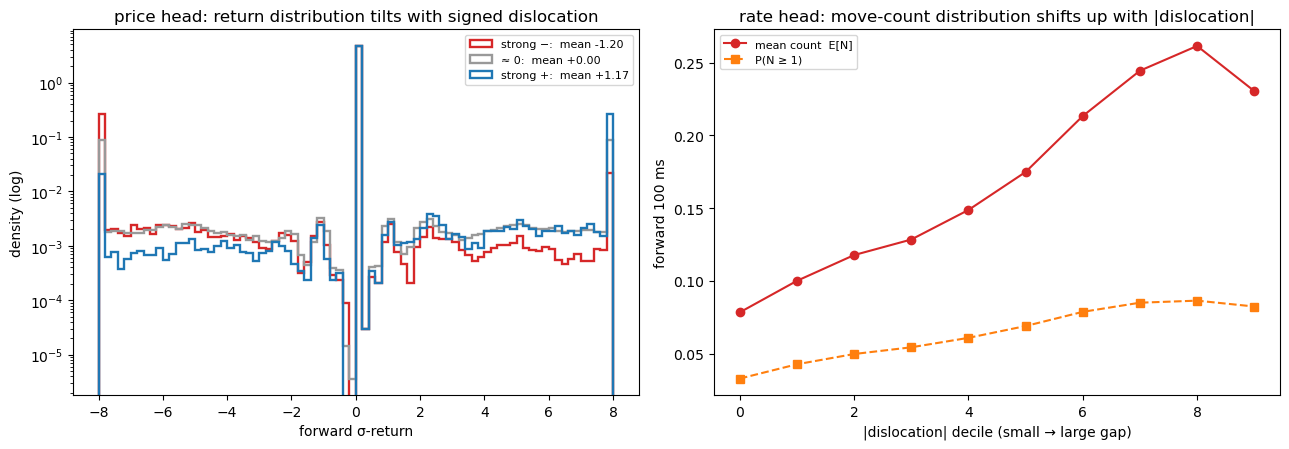

In [7]:
signed = price_dislocation(spreads["bin"], FAST[bp[0]], SLOW[bp[1]])            # best price member (signed)
absmag = np.abs(price_dislocation(spreads["bin"], FAST[br[0]], SLOW[br[1]]))    # best rate member (|·|)
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# price head: forward σ-return distribution across signed-dislocation buckets
lo, hi = np.nanpercentile(signed, [10, 90])
groups = [("strong −", signed <= lo, "C3"), ("≈ 0", (signed > lo) & (signed < hi), "0.6"),
          ("strong +", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    axA.hist(np.clip(target[m & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[m]):+.2f}")
axA.set_yscale("log"); axA.set_xlabel("forward σ-return"); axA.set_ylabel("density (log)")
axA.set_title("price head: return distribution tilts with signed dislocation"); axA.legend(fontsize=8)

# rate head: forward move-count shifts up with |dislocation|
dec = np.digitize(absmag, np.nanpercentile(absmag, np.arange(10, 100, 10)))
axB.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[N]")
axB.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(N ≥ 1)")
axB.set_xlabel("|dislocation| decile (small → large gap)"); axB.set_ylabel("forward 100 ms")
axB.set_title("rate head: move-count distribution shifts up with |dislocation|"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

## 5d. Feature distribution → how to normalise it for the net

Two *different* normalisations. The `σ_ev` division in the definition makes the feature
**regime-invariant** (done, §2). A separate **NN-input** transform standardises its scale
and tames outliers for training — and you decide *that* one from the feature's own
**shape**: plot it (left), then compare candidate transforms by how Gaussian *and*
bounded they make it (right: QQ vs N(0,1) — the one on the diagonal without runaway tails
wins). Pick the **lightest adequate** transform; don't over-squash.

feature: std=10.0  skew=+0.00  excess_kurt=1.1  (0 = normal)
  z-score            excess_kurt=   1.1   max|·|=23.3
  robust + clip ±4   excess_kurt=   0.3   max|·|=4.0
  arcsinh(robust)    excess_kurt=  -0.8   max|·|=3.9
  rank-Gaussian      excess_kurt=  -0.0   max|·|=5.0


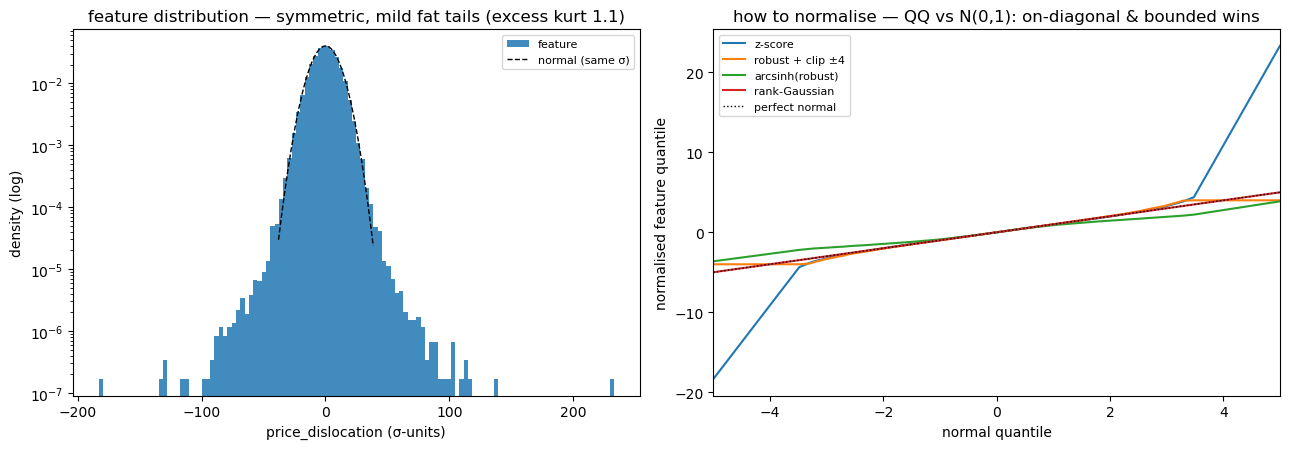

In [8]:
from scipy.stats import skew, kurtosis, rankdata, norm
f = price_dislocation(spreads["bin"], FAST[bp[0]], SLOW[bp[1]]); f = f[np.isfinite(f)]
med = np.median(f); mad = 1.4826 * np.median(np.abs(f - med)); rz = (f - med) / mad
cand = {"z-score": (f - f.mean()) / f.std(),
        "robust + clip ±4": np.clip(rz, -4, 4),
        "arcsinh(robust)": np.arcsinh(rz),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"feature: std={f.std():.1f}  skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:18} excess_kurt={kurtosis(v):>6.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(f, bins=120, density=True, color="C0", alpha=.85, label="feature")
xg = np.linspace(np.percentile(f, 0.05), np.percentile(f, 99.95), 300)
axA.plot(xg, norm.pdf(xg, f.mean(), f.std()), "k--", lw=1, label="normal (same σ)")
axA.set_yscale("log"); axA.set_xlabel("price_dislocation (σ-units)"); axA.set_ylabel("density (log)")
axA.set_title(f"feature distribution — symmetric, mild fat tails (excess kurt {kurtosis(f):.1f})")
axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Read-out (this feature).** It's **symmetric** (skew ≈ 0) with only **mild fat tails**
(excess kurt ≈ 1) — because it's already `/σ_ev`. So a plain **z-score** suffices, or
**robust-scale + clip ±4** if you want bounded inputs; `arcsinh` over-compresses
(sub-Gaussian) and a rank-Gaussian transform is overkill and throws away magnitude. A
heavily skewed or kurtotic feature (excess kurt ≫ 1) would instead push you toward
arcsinh / rank — the plot *is* the decision.

**Gates still to run** (harness above is reusable): **4 stratified leak** (gate-3
increment inside `lv` deciles), **6 incremental/collinear** (add over the existing set;
bin vs okx, and neighbouring family members, are partly redundant), **7 temporal
stationarity** (per-day CV of the IC), **8 OOS across a regime gap** (train/test on
different days).

## 6. Disposition · 7. Ship checklist

**Disposition — KEEP, in BOTH heads, as a small family** (each head picks its corner):
- **Price head (direction)** — *signed*, a **smoothed fast leg over a slow leg**
  (≈ `N_fast 10–50`, `N_slow 2000–5000`); the leader `bin_eth_usdt_p` carries most of it.
  The instantaneous `N_fast=1` is *worse* here — its single-tick noise dilutes direction.
- **Rate head (intensity)** — `|·|`, the **instantaneous fast leg / faster slow leg**
  (`N_fast=1`, `N_slow ≈ 100`); intensity keys off the *immediate* gap, so smoothing hurts.

Keep a few non-redundant `(N_fast, N_slow)` members per head, not the whole grid; pool
bin/okx toward a consensus basis. Both heads share the `σ_ev` yardstick.

- [ ] streaming `IFeatureBuilder` (two level `ScalarEMA`s of the spread per listing·member + shared `σ_ev`) — O(1)
- [ ] oracle trio in `tests/` (blind loop + synthetic + real-block diff), suite green
- [ ] gate table filled; leak/incremental/normalizer justified if failing
- [ ] head routing + chosen `(N_fast,N_slow)` members recorded in `docs/nn_features.md`; `σ_ev` lookback matches the target
- [ ] data traps handled (zero-prints; merged_levels blocked for bin perp → front_levels mid)